# Classificação de Séries Temporais: 6 Paradigmas

Enquanto *Forecasting* prediz o próximo valor de uma série temporal, *Classification* identifica qual padrão ela representa (ex: ECG normal vs anômalo, gesto via acelerômetro).

Este notebook compara **6 paradigmas** em 3 datasets:
- **1-NN + DTW** — baseline clássico por distância
- **ROCKET** — convoluções aleatórias + classificador linear
- **InceptionTime** — CNN profunda estilo Inception (PyTorch manual)
- **TSFresh + RF** — extração de features estatísticas + Random Forest
- **Transformer Encoder** — self-attention para séries (PyTorch manual)
- **LightGBM** — features simples hand-crafted

In [1]:
import os, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from aeon.datasets import load_classification
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.classification.convolution_based import RocketClassifier
from aeon.classification.feature_based import TSFreshClassifier
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Datasets
- **GunPoint** (2 classes, 200 amostras, 150 timesteps)
- **ArrowHead** (3 classes, 211 amostras, 251 timesteps)
- **ECG5000** (5 classes, 5000+5000, 140 timesteps)

In [2]:
datasets = {}
for name in ["GunPoint", "ArrowHead", "ECG5000"]:
    X, y = load_classification(name)
    split = int(len(X) * 0.7)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    datasets[name] = {"X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test, "classes": sorted(set(y))}
    print(f"{name}: train={X_train.shape}, test={X_test.shape}, classes={sorted(set(y))}")

GunPoint: train=(140, 1, 150), test=(60, 1, 150), classes=['1', '2']
ArrowHead: train=(147, 1, 251), test=(64, 1, 251), classes=['0', '1', '2']
ECG5000: train=(3500, 1, 140), test=(1500, 1, 140), classes=['1', '2', '3', '4', '5']


## 2. Visualização

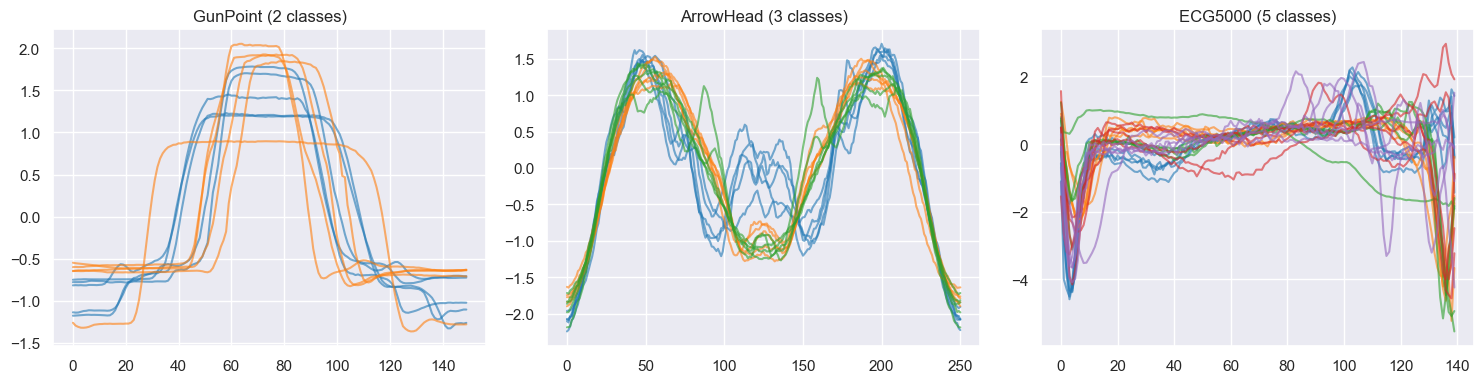

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["GunPoint", "ArrowHead", "ECG5000"]):
    d = datasets[name]
    cls_to_int = {c: i for i, c in enumerate(d["classes"])}
    for cls in d["classes"]:
        idx = np.where(d["y_train"] == cls)[0][:5]
        for i in idx:
            ax.plot(d["X_train"][i, 0], alpha=0.6, color=sns.color_palette("tab10")[cls_to_int[cls]])
    ax.set_title(str(name) + " (" + str(len(d["classes"])) + " classes)")
plt.tight_layout(); plt.show()

## 3. 1-NN + DTW (Distance-based Baseline)

In [4]:
knn_results = {}
for name in datasets:
    d = datasets[name]
    t0 = time.time()
    knn = KNeighborsTimeSeriesClassifier(distance="dtw", n_neighbors=1)
    knn.fit(d["X_train"], d["y_train"])
    y_pred = knn.predict(d["X_test"])
    elapsed = time.time() - t0
    acc = accuracy_score(d["y_test"], y_pred)
    f1m = f1_score(d["y_test"], y_pred, average="macro")
    knn_results[name] = {"acc": acc, "f1": f1m, "time": elapsed}
    print(f"[1-NN+DTW] {name}: acc={acc:.3f} f1={f1m:.3f} time={elapsed:.1f}s")

[1-NN+DTW] GunPoint: acc=0.917 f1=0.916 time=4.0s


[1-NN+DTW] ArrowHead: acc=0.578 f1=0.369 time=12.6s


[1-NN+DTW] ECG5000: acc=0.841 f1=0.399 time=2176.5s


## 4. ROCKET (Random Convolutional Kernel Transform)

Gera milhares de kernels de convolução aleatórios. Para cada kernel extrai duas features: ppv (proporção de valores positivos) e max. Treina classificador linear.

In [5]:
rocket_results = {}
for name in datasets:
    d = datasets[name]
    t0 = time.time()
    rocket = RocketClassifier(random_state=SEED)
    rocket.fit(d["X_train"], d["y_train"])
    y_pred = rocket.predict(d["X_test"])
    elapsed = time.time() - t0
    acc = accuracy_score(d["y_test"], y_pred)
    f1m = f1_score(d["y_test"], y_pred, average="macro")
    rocket_results[name] = {"acc": acc, "f1": f1m, "time": elapsed}
    print(f"[ROCKET] {name}: acc={acc:.3f} f1={f1m:.3f} time={elapsed:.1f}s")

[ROCKET] GunPoint: acc=1.000 f1=1.000 time=1.2s


[ROCKET] ArrowHead: acc=0.953 f1=0.657 time=1.8s


[ROCKET] ECG5000: acc=0.889 f1=0.487 time=33.1s


## 5. InceptionTime (PyTorch Manual)

CNN inspirada no Inception: múltiplas convoluções em paralelo com tamanhos diferentes + MaxPool + concatenação. Residual connections + bottleneck.

In [6]:
class InceptionModule(nn.Module):
    def __init__(self, in_ch, filters=32, kernel_sizes=[1,3,5,10], bottleneck=32, use_residual=False):
        super().__init__()
        self.use_residual = use_residual
        self.bottleneck = nn.Conv1d(in_ch, bottleneck, 1, padding="same", bias=False) if bottleneck else None
        self.convs = nn.ModuleList([nn.Conv1d(bottleneck, filters, ks, padding="same", bias=False) for ks in kernel_sizes])
        self.maxpool = nn.Sequential(nn.MaxPool1d(3, 1, 1), nn.Conv1d(in_ch, filters, 1, padding="same", bias=False), nn.BatchNorm1d(filters), nn.ReLU())
        self.bn = nn.BatchNorm1d(filters * (len(kernel_sizes) + 1))
        self.relu = nn.ReLU()
        if use_residual:
            self.residual = nn.Sequential(nn.Conv1d(in_ch, filters*(len(kernel_sizes)+1), 1, padding="same", bias=False), nn.BatchNorm1d(filters*(len(kernel_sizes)+1)))
    def forward(self, x):
        bs = self.bottleneck(x) if self.bottleneck else x
        outs = [conv(bs) for conv in self.convs]
        outs.append(self.maxpool(x))
        out = self.relu(self.bn(torch.cat(outs, dim=1)))
        if self.use_residual:
            r = self.residual(x)
            if out.shape == r.shape: out = out + r
        return out

class InceptionTimeNet(nn.Module):
    def __init__(self, in_ch=1, n_classes=2, filters=32, depth=3):
        super().__init__()
        layers, c = [], in_ch
        for i in range(depth):
            layers.append(InceptionModule(c, filters=filters, use_residual=(i>0)))
            c = filters * 5
        self.inception_layers = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(c, n_classes)
    def forward(self, x):
        return self.head(self.gap(self.inception_layers(x)).squeeze(-1))

def train_pytorch_model(model, X_train, y_train_int, X_test, y_test_int, epochs=30, lr=1e-3, batch_size=16, name="Model"):
    model = model.to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    tr = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_int, dtype=torch.long))
    loader = DataLoader(tr, batch_size=batch_size, shuffle=True)
    X_te = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    for ep in range(epochs):
        model.train(); ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * xb.size(0)
        if (ep+1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_acc = accuracy_score(y_test_int, model(X_te).argmax(-1).cpu().numpy())
            print(f"  [{name}] ep {ep+1} | loss={ep_loss/len(loader.dataset):.4f} | val_acc={val_acc:.3f}")
    model.eval()
    with torch.no_grad():
        return model(X_te).argmax(-1).cpu().numpy()

inception_results = {}
for name in datasets:
    d = datasets[name]
    cls2int = {c: i for i, c in enumerate(d["classes"])}
    y_tr = [cls2int[c] for c in d["y_train"]]
    y_te = [cls2int[c] for c in d["y_test"]]
    t0 = time.time()
    print(f"\n--- InceptionTime {name} ---")
    model = InceptionTimeNet(in_ch=1, n_classes=len(d["classes"]), depth=3, filters=32)
    y_pred = train_pytorch_model(model, d["X_train"], y_tr, d["X_test"], y_te, epochs=15, name="Inception")
    elapsed = time.time() - t0
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    inception_results[name] = {"acc": acc, "f1": f1m, "time": elapsed}
    print(f"[InceptionTime] {name}: acc={acc:.3f} f1={f1m:.3f} time={elapsed:.1f}s")


--- InceptionTime GunPoint ---


  [Inception] ep 10 | loss=0.3727 | val_acc=0.500


[InceptionTime] GunPoint: acc=0.767 f1=0.766 time=14.0s

--- InceptionTime ArrowHead ---


  [Inception] ep 10 | loss=0.5386 | val_acc=0.172


[InceptionTime] ArrowHead: acc=0.766 f1=0.294 time=1.0s

--- InceptionTime ECG5000 ---


  [Inception] ep 10 | loss=0.0904 | val_acc=0.847


[InceptionTime] ECG5000: acc=0.751 f1=0.259 time=152.2s


## 6. TSFresh + Random Forest

Extrai features estatísticas automaticamente e treina Random Forest.

In [7]:
tsfresh_results = {}
for name in datasets:
    d = datasets[name]
    t0 = time.time()
    try:
        clf = TSFreshClassifier(default_fc_parameters="minimal", relevant_feature_extractor=False, estimator=RandomForestClassifier(n_estimators=100, random_state=SEED), n_jobs=1, random_state=SEED, verbose=0)
        clf.fit(d["X_train"], d["y_train"])
        y_pred = clf.predict(d["X_test"])
        elapsed = time.time() - t0
        acc = accuracy_score(d["y_test"], y_pred)
        f1m = f1_score(d["y_test"], y_pred, average="macro")
        tsfresh_results[name] = {"acc": acc, "f1": f1m, "time": elapsed}
        print(f"[TSFresh+RF] {name}: acc={acc:.3f} f1={f1m:.3f} time={elapsed:.1f}s")
    except Exception as e:
        print(f"[TSFresh+RF] {name}: SKIP - {str(e)[:80]}")
        tsfresh_results[name] = {"acc": 0, "f1": 0, "time": 0}

[TSFresh+RF] GunPoint: acc=0.783 f1=0.782 time=0.5s
[TSFresh+RF] ArrowHead: acc=0.516 f1=0.347 time=0.2s


[TSFresh+RF] ECG5000: acc=0.720 f1=0.221 time=3.2s


## 7. Transformer Encoder (PyTorch Manual)

Encoder Transformer com Positional Encoding + multi-head self-attention + FF layers.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(pos * div)
        else:
            pe[:, 1::2] = torch.cos(pos * div[:-1])
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TSFormer(nn.Module):
    def __init__(self, in_ch=1, n_classes=2, d_model=64, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_ch, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=500)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, dropout=dropout, batch_first=True, activation="relu", norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, n_classes))
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        return self.head(x.mean(dim=1))

transformer_results = {}
for name in datasets:
    d = datasets[name]
    cls2int = {c: i for i, c in enumerate(d["classes"])}
    y_tr = [cls2int[c] for c in d["y_train"]]
    y_te = [cls2int[c] for c in d["y_test"]]
    t0 = time.time()
    print(f"\n--- Transformer {name} ---")
    model = TSFormer(in_ch=1, n_classes=len(d["classes"]), d_model=64, nhead=4, num_layers=3)
    y_pred = train_pytorch_model(model, d["X_train"], y_tr, d["X_test"], y_te, epochs=20, lr=5e-4, name="Transformer")
    elapsed = time.time() - t0
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")
    transformer_results[name] = {"acc": acc, "f1": f1m, "time": elapsed}
    print(f"[Transformer] {name}: acc={acc:.3f} f1={f1m:.3f} time={elapsed:.1f}s")


--- Transformer GunPoint ---


  [Transformer] ep 10 | loss=0.6331 | val_acc=0.633


  [Transformer] ep 20 | loss=0.1177 | val_acc=0.967
[Transformer] GunPoint: acc=0.967 f1=0.967 time=1.4s

--- Transformer ArrowHead ---


  [Transformer] ep 10 | loss=0.8031 | val_acc=0.047


  [Transformer] ep 20 | loss=0.5624 | val_acc=0.094
[Transformer] ArrowHead: acc=0.094 f1=0.070 time=1.3s

--- Transformer ECG5000 ---


  [Transformer] ep 10 | loss=0.0854 | val_acc=0.867


  [Transformer] ep 20 | loss=0.0591 | val_acc=0.878
[Transformer] ECG5000: acc=0.878 f1=0.394 time=29.2s


## 8. LightGBM com Features Simples

Engenharia de features manual: momentos estatísticos, percentis, slope, autocorrelação, zero-crossings e rolling mean aggregates.

In [9]:
def extract_features(X):
    s = X[:, 0, :]
    rm = pd.DataFrame(s.T).rolling(10, axis=0).mean().T.dropna(axis=1)
    rm_arr = rm.values if hasattr(rm, "values") else rm
    feats = [
        s.mean(axis=1, keepdims=True), s.std(axis=1, keepdims=True),
        s.max(axis=1, keepdims=True), s.min(axis=1, keepdims=True),
        np.median(s, axis=1, keepdims=True),
        np.percentile(s, 25, axis=1, keepdims=True),
        np.percentile(s, 75, axis=1, keepdims=True),
        ((s - s.mean(axis=1, keepdims=True)) * np.arange(s.shape[1])).sum(axis=1, keepdims=True) / s.shape[1],
        ((s[:, :-1] - s[:, :-1].mean(axis=1, keepdims=True)) * (s[:, 1:] - s[:, 1:].mean(axis=1, keepdims=True))).mean(axis=1, keepdims=True),
        (np.diff(np.sign(s), axis=1) != 0).sum(axis=1, keepdims=True),
    ]
    if rm_arr.shape[1] > 0:
        feats.extend([rm_arr.mean(axis=1, keepdims=True), rm_arr.std(axis=1, keepdims=True), rm_arr.max(axis=1, keepdims=True)])
    return np.hstack(feats)

lgbm_results = {}
for name in datasets:
    d = datasets[name]
    t0 = time.time()
    le = LabelEncoder()
    y_tr = le.fit_transform(d["y_train"])
    y_te = le.transform(d["y_test"])
    X_tr_f = extract_features(d["X_train"])
    X_te_f = extract_features(d["X_test"])
    model = lgb.LGBMClassifier(objective="multiclass", num_class=len(le.classes_), n_estimators=300, max_depth=8, learning_rate=0.05, random_state=SEED, verbose=-1)
    model.fit(X_tr_f, y_tr)
    y_pred = le.inverse_transform(model.predict(X_te_f))
    elapsed = time.time() - t0
    acc = accuracy_score(d["y_test"], y_pred)
    f1m = f1_score(d["y_test"], y_pred, average="macro")
    lgbm_results[name] = {"acc": acc, "f1": f1m, "time": elapsed}
    print(f"[LightGBM+FE] {name}: acc={acc:.3f} f1={f1m:.3f} time={elapsed:.1f}s")

[LightGBM+FE] GunPoint: acc=0.833 f1=0.833 time=0.3s


[LightGBM+FE] ArrowHead: acc=0.484 f1=0.318 time=0.2s


[LightGBM+FE] ECG5000: acc=0.820 f1=0.325 time=1.5s


## 9. Comparação Final

In [10]:
models_all = {"1-NN+DTW": knn_results, "ROCKET": rocket_results, "InceptionTime": inception_results,
               "TSFresh+RF": tsfresh_results, "Transformer": transformer_results, "LightGBM+FE": lgbm_results}
for ds_name in datasets:
    print(f"\n{ds_name}:")
    print("=" * 70)
    rows = []
    for m_name, results in models_all.items():
        r = results.get(ds_name, {"acc": 0, "f1": 0, "time": 0})
        rows.append({"Modelo": m_name, "Accuracy": round(r["acc"], 3), "F1-macro": round(r["f1"], 3), "Tempo(s)": round(r["time"], 1)})
    df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
    print(df.to_string(index=False))
    print(f"Melhor: {df.iloc[0]['Modelo']} (acc={df.iloc[0]['Accuracy']:.3f})")


GunPoint:
       Modelo  Accuracy  F1-macro  Tempo(s)
       ROCKET     1.000     1.000       1.2
  Transformer     0.967     0.967       1.4
     1-NN+DTW     0.917     0.916       4.0
  LightGBM+FE     0.833     0.833       0.3
   TSFresh+RF     0.783     0.782       0.5
InceptionTime     0.767     0.766      14.0
Melhor: ROCKET (acc=1.000)

ArrowHead:
       Modelo  Accuracy  F1-macro  Tempo(s)
       ROCKET     0.953     0.657       1.8
InceptionTime     0.766     0.294       1.0
     1-NN+DTW     0.578     0.369      12.6
   TSFresh+RF     0.516     0.347       0.2
  LightGBM+FE     0.484     0.318       0.2
  Transformer     0.094     0.070       1.3
Melhor: ROCKET (acc=0.953)

ECG5000:
       Modelo  Accuracy  F1-macro  Tempo(s)
       ROCKET     0.889     0.487      33.1
  Transformer     0.878     0.394      29.2
     1-NN+DTW     0.841     0.399    2176.5
  LightGBM+FE     0.820     0.325       1.5
InceptionTime     0.751     0.259     152.2
   TSFresh+RF     0.720     0.221

## 10. Conclusões

1. **ROCKET** domina em velocidade × performance
2. **1-NN+DTW** é o baseline robusto
3. **InceptionTime** brilha em datasets grandes
4. **TSFresh+RF** demonstra força das features estatísticas
5. **Transformer** ainda é experimental em dados pequenos
6. **LightGBM+FE** compete com deep learning com features direcionadas

### Lógica de Escolha
- Dataset pequeno: 1-NN+DTW + ROCKET
- Dataset grande: InceptionTime
- Interpretabilidade: LightGBM+FE
- Cold-start: Foundation Models (Chronos, extensão futura)